In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [53]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

In [54]:
df_DA_US_exploded = df_DA_US.explode('job_skills')

In [55]:
df_DA_skill = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count', ascending=False)

df_DA_skill = df_DA_skill.rename(columns={'count':'skill_count', 'median':'median_salary'})

In [56]:
DA_job_count = len(df_DA_US)

df_DA_skill['skill_percent'] = df_DA_skill['skill_count']/DA_job_count * 100

df_DA_skill

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
theano,1,100000.0,0.022989
typescript,1,65000.0,0.022989
vmware,1,147500.0,0.022989


In [57]:
skill_percent = 5

df_DA_skill_high_demand = df_DA_skill[df_DA_skill['skill_percent']>5]

df_DA_skill_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


0 sql
1 excel
2 python
3 tableau
4 sas
5 r
6 power bi
7 powerpoint
8 word
9 sql server
10 oracle
11 go


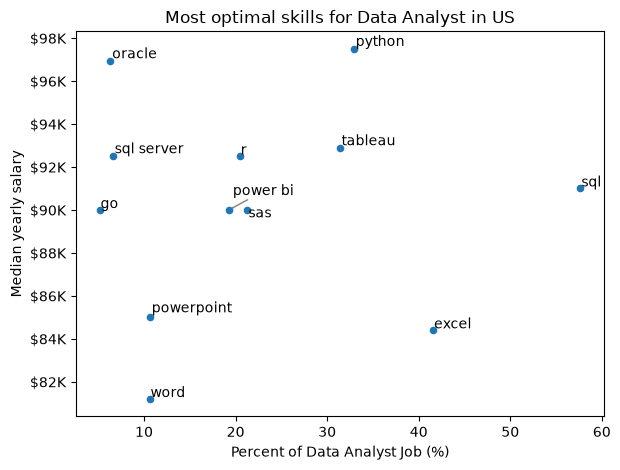

In [58]:
from adjustText import adjust_text

df_DA_skill_high_demand.plot(kind='scatter', x='skill_percent',y='median_salary')
plt.xlabel('Percent of Data Analyst Job (%)')
plt.ylabel('Median yearly salary')
plt.title('Most optimal skills for Data Analyst in US')
plt.tight_layout()

text = []
for i, txt in enumerate(df_DA_skill_high_demand.index):
    print(i, txt)
    text.append(plt.text(df_DA_skill_high_demand['skill_percent'].iloc[i],df_DA_skill_high_demand['median_salary'].iloc[i], txt ))

adjust_text(text, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.show()

In [59]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing list
            technology_dict[key] += value
        else:  # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['word',
  'sap',
  'esquisse',
  'qlik',
  'ssis',
  'msaccess',
  'spss',
  'sas',
  'cognos',
  'tableau',
  'power bi',
  'dax',
  'looker',
  'powerpoint',
  'sharepoint',
  'nuix',
  'microstrategy',
  'splunk',
  'sheets',
  'spreadsheet',
  'outlook',
  'datarobot',
  'powerbi',
  'excel',
  'visio',
  'alteryx',
  'ssrs',
  'ms access'],
 'programming': ['shell',
  'php',
  'rust',
  'sass',
  'swift',
  'elixir',
  'powershell',
  'perl',
  't-sql',
  'dart',
  'pascal',
  'sas',
  'python',
  'nosql',
  'c#',
  'solidity',
  'scala',
  'clojure',
  'apl',
  'html',
  'java',
  'objective-c',
  'kotlin',
  'lua',
  'c',
  'r',
  'julia',
  'golang',
  'mongodb',
  'visual basic',
  'f#',
  'no-sql',
  'vba',
  'groovy',
  'lisp',
  'bash',
  'mongo',
  'vb.net',
  'css',
  'delphi',
  'ocaml',
  'visualbasic',
  'javascript',
  'fortran',
  'cobol',
  'assembly',
  'c++',
  'go',
  'ruby',
  'crystal',
  'typescript',
  'matlab',
  'haskell',
  'erlang',
  '

In [60]:
df_technology = pd.DataFrame(
    list(technology_dict.items()), columns=['technology', 'skills']
)

df_technology

,technology,skills
0,analyst_tools,"[word, sap, esquisse, qlik, ssis, msaccess, sp..."
1,programming,"[shell, php, rust, sass, swift, elixir, powers..."
2,cloud,"[azure, bigquery, heroku, redshift, firebase, ..."
3,libraries,"[scikit-learn, selenium, dplyr, rshiny, xamari..."
4,other,"[pulumi, chef, puppet, homebrew, unity, jenkin..."
5,databases,"[mariadb, mongodb, firestore, firebase, elasti..."
6,os,"[debian, centos, arch, ubuntu, unix, fedora, r..."
7,async,"[microsoft lists, wimi, workfront, jira, confl..."
8,webframeworks,"[svelte, ember.js, node.js, react.js, express,..."
9,sync,"[unify, google chat, symphony, webex, wire, ro..."


In [61]:
df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,word
0,analyst_tools,sap
0,analyst_tools,esquisse
0,analyst_tools,qlik
0,analyst_tools,ssis
...,...,...
9,sync,mattermost
9,sync,slack
9,sync,ringcentral
9,sync,zoom


In [62]:
df_plot_6 = df_DA_skill_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

df_plot_6

,skill_count,median_salary,skill_percent,technology,skills
0,2508,91000.00,57.655172,programming,sql
1,1808,84392.00,41.563218,analyst_tools,excel
2,1431,97500.00,32.896552,programming,python
3,1364,92875.00,31.356322,analyst_tools,tableau
4,926,90000.00,21.287356,analyst_tools,sas
5,926,90000.00,21.287356,programming,sas
6,893,92500.00,20.528736,programming,r
7,838,90000.00,19.264368,analyst_tools,power bi
8,462,85000.00,10.620690,analyst_tools,powerpoint
9,461,81194.75,10.597701,analyst_tools,word


0 sql
1 excel
2 python
3 tableau
4 sas
5 r
6 power bi
7 powerpoint
8 word
9 sql server
10 oracle
11 go


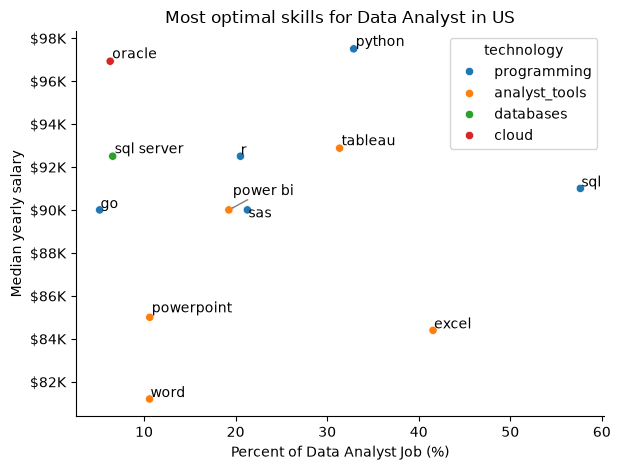

In [67]:
from adjustText import adjust_text

# df_plot_6.plot(kind='scatter', x='skill_percent',y='median_salary')
sns.scatterplot(data=df_plot_6, x='skill_percent', y='median_salary', hue='technology')
sns.despine()

plt.xlabel('Percent of Data Analyst Job (%)')
plt.ylabel('Median yearly salary')
plt.title('Most optimal skills for Data Analyst in US')
plt.tight_layout()

text = []
for i, txt in enumerate(df_DA_skill_high_demand.index):
    print(i, txt)
    text.append(plt.text(df_DA_skill_high_demand['skill_percent'].iloc[i],df_DA_skill_high_demand['median_salary'].iloc[i], txt ))

adjust_text(text, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.show()